## Kuvantunnistusjärjestelmä

Tässä projektissa toteutetaan kuvantunnistusjärjestelmä, joka oppii tunnistamaan kolme eri luokkaa: mukit (mugs), pullot (bottles) ja kirjat (books). Projektin tavoitteena on ymmärtää, miten erilaiset syväoppimisen mallit toimivat kuvantunnistuksessa ja miten niiden suorituskyky vaihtelee.

Projektissa käytetään itse kerättyä kuvadataa, jossa on 50 kuvaa jokaisesta luokasta. Kuvat on jaettu harjoitus-, validointi- ja testiaineistoihin, jotta mallien oppimista ja yleistämiskykyä voidaan arvioida mahdollisimman realistisesti.

Työssä toteutetaan kolme erilaista mallia:

Yksinkertainen konvoluutioneuroverkko (CNN), joka opetetaan alusta alkaen
Esikoulutettu VGG16-malli piirteiden erotteluun
Hienosäädetty VGG16-malli, jossa osia verkosta opetetaan uudelleen

Projektin tarkoituksena on vertailla näiden lähestymistapojen eroja sekä tarkkuutta että yleistämiskykyä käyttäen samaa datasettiä. Lisäksi analysoidaan mallien vahvuuksia ja heikkouksia pienellä kuvadatalla.

### Importit

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

### Datan lataus

Kuvat ladataan kansiorakenteesta. Jokainen kansio vastaa yhtä luokkaa (mugs, bottles, flowers). Kuvat muutetaan automaattisesti samaan kokoon (224x224).

In [2]:
img_size = (224, 224)
batch_size = 16

train_ds = keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=img_size,
    batch_size=batch_size
)

val_ds = keras.utils.image_dataset_from_directory(
    "dataset/val",
    image_size=img_size,
    batch_size=batch_size
)

test_ds = keras.utils.image_dataset_from_directory(
    "dataset/test",
    image_size=img_size,
    batch_size=batch_size
)

Found 105 files belonging to 3 classes.


Found 21 files belonging to 3 classes.
Found 24 files belonging to 3 classes.


### Esikäsittely + augmentaatio

Kuvia muokataan hieman, jotta malli oppii paremmin erilaisia tilanteita. Tämä parantaa yleistämistä.

In [3]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

normalization = layers.Rescaling(1./255)

### MALLI 1: Oma CNN 

Tämä on yksinkertainen konvoluutioneuroverkko, joka opetetaan täysin alusta. Se toimii vertailupohjana muille malleille.

In [4]:
model1 = keras.Sequential([
    normalization,
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

Mallia opetetaan training-datalla ja seurataan validointia.

In [5]:
model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 671ms/step - accuracy: 0.3143 - loss: 2.9624 - val_accuracy: 0.3333 - val_loss: 1.0878
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 568ms/step - accuracy: 0.3429 - loss: 1.0965 - val_accuracy: 0.4762 - val_loss: 1.0733
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 559ms/step - accuracy: 0.4667 - loss: 1.0612 - val_accuracy: 0.4286 - val_loss: 1.0791
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 496ms/step - accuracy: 0.5048 - loss: 0.9402 - val_accuracy: 0.5238 - val_loss: 1.0039
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 555ms/step - accuracy: 0.7429 - loss: 0.6913 - val_accuracy: 0.3810 - val_loss: 1.3587
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 537ms/step - accuracy: 0.7810 - loss: 0.5395 - val_accuracy: 0.7143 - val_loss: 1.1217
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 584ms/step - accuracy: 0.8381 - loss: 0.3638 - val_accuracy: 0.5714 - val_loss: 1.7778
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 543ms/step - accuracy: 0.8095 - loss: 0.4790 - val_accuracy: 0.8571 - val_loss:

### MALLI 2: VGG16 feature extraction

Käytetään valmiiksi opetettua VGG16-mallia. Se tunnistaa kuvista yleisiä piirteitä (reunat, muodot), mutta ei itse opi luokkia.

In [6]:
base_model = keras.applications.VGG16(
    include_top=False,
    input_shape=(224, 224, 3),
    weights='imagenet'
)

base_model.trainable = False

Lisätään oma "päätöskerros", joka oppii luokat.

In [7]:
model2 = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.4571 - loss: 2.6812 - val_accuracy: 0.5714 - val_loss: 1.4741
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8381 - loss: 0.3471 - val_accuracy: 0.5714 - val_loss: 1.3586
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9048 - loss: 0.2308 - val_accuracy: 0.5714 - val_loss: 1.2462
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9238 - loss: 0.1623 - val_accuracy: 0.6667 - val_loss: 1.2292
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9429 - loss: 0.0904 - val_accuracy: 0.6190 - val_loss: 1.4648
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9810 - loss: 0.0779 - val_accuracy: 0.6667 - val_loss: 1.1789
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9810 - loss: 0.0491 - val_accuracy: 0.6667 - val_loss: 1.1862
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9714 - loss: 0.0451 - val_accuracy: 0.6667 - val_loss: 1.2117
Epoch 9/10

### MALLI 3: Fine-tuning VGG16

Tässä mallissa VGG16:n viimeisiä kerroksia opetetaan uudelleen omalla datalla. Tämä yleensä parantaa tarkkuutta.

In [8]:
base_model.trainable = True

# jäädytetään alemmat kerrokset
for layer in base_model.layers[:15]:
    layer.trainable = False

In [9]:
model3 = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model3.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3238 - loss: 2.9974 - val_accuracy: 0.7143 - val_loss: 1.9187
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5810 - loss: 1.0271 - val_accuracy: 0.5238 - val_loss: 1.7092
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8381 - loss: 0.3900 - val_accuracy: 0.4762 - val_loss: 1.5003
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9524 - loss: 0.2168 - val_accuracy: 0.4762 - val_loss: 1.1999
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9714 - loss: 0.1200 - val_accuracy: 0.6667 - val_loss: 1.0204


### Mallien vertailu

Testidatalla tarkistetaan, mikä malli toimii parhaiten oikeassa käytössä.

In [10]:
print("CNN:", model1.evaluate(test_ds))
print("VGG16 feature:", model2.evaluate(test_ds))
print("Fine-tuned:", model3.evaluate(test_ds))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.7500 - loss: 0.7586
CNN: [0.7585976123809814, 0.75]
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 549ms/step - accuracy: 0.7500 - loss: 1.2508
VGG16 feature: [1.2508331537246704, 0.75]
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 551ms/step - accuracy: 0.7500 - loss: 0.7699
Fine-tuned: [0.7698813080787659, 0.75]


### Oppimiskäyrät

Kuvataan, miten tarkkuus kehittyy harjoituksen aikana.

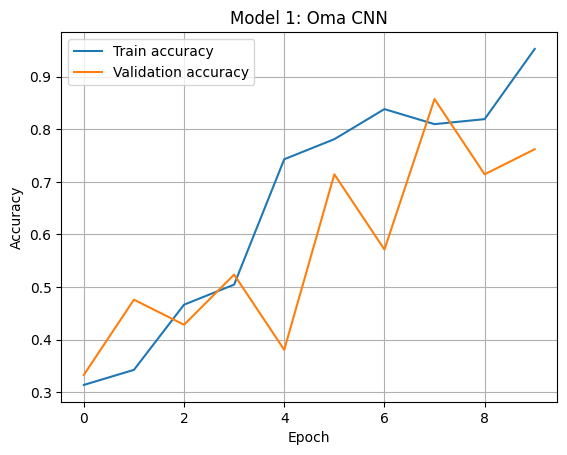

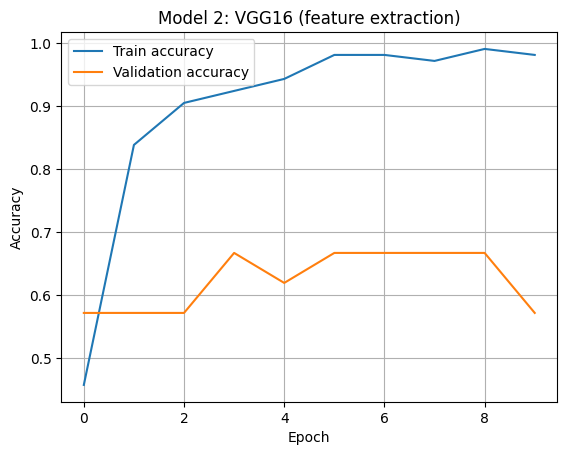

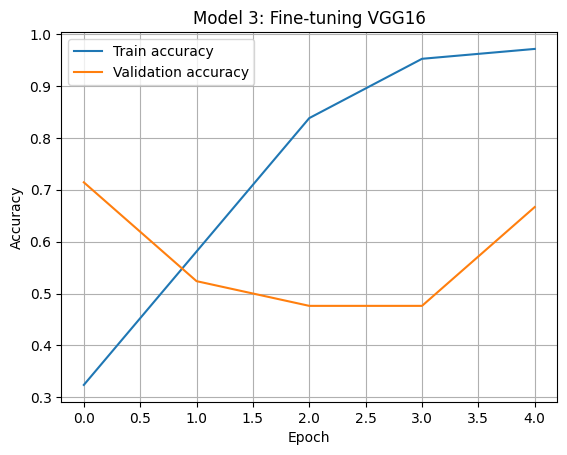

In [11]:
def plot_history(history, title):
    plt.figure()
    
    plt.plot(history.history['accuracy'], label='Train accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation accuracy')
    
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    
    plt.legend()
    plt.grid()
    plt.show()
    
plot_history(history1, "Model 1: Oma CNN")
plot_history(history2, "Model 2: VGG16 (feature extraction)")
plot_history(history3, "Model 3: Fine-tuning VGG16")

### Väärin luokitellut kuvat

Tarkastellaan esimerkkejä, joissa malli teki virheen. Tämä auttaa ymmärtämään mallin heikkouksia.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


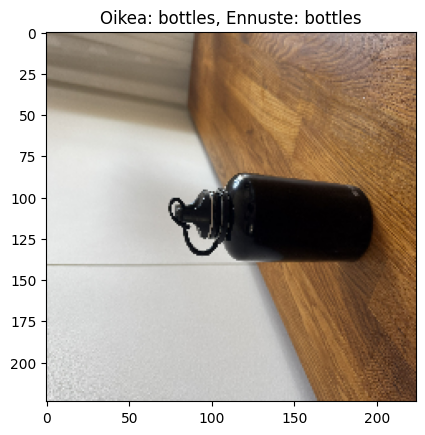

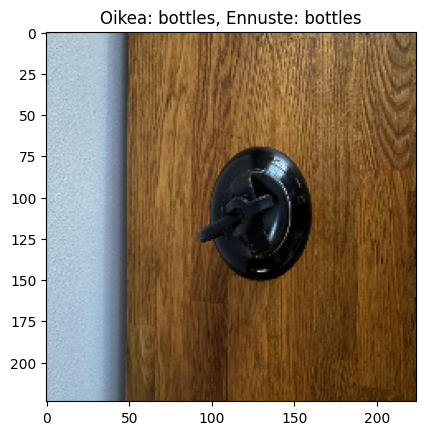

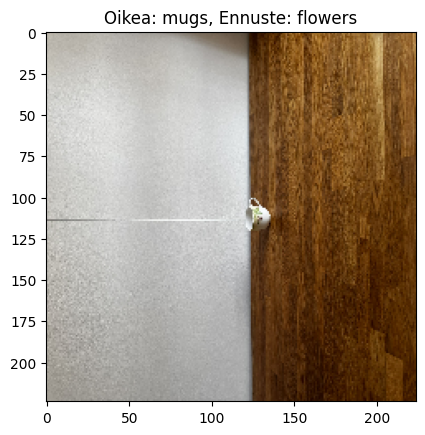

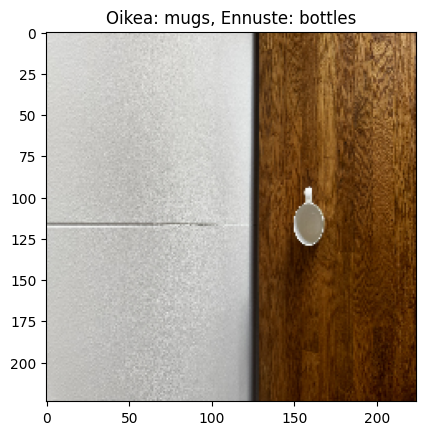

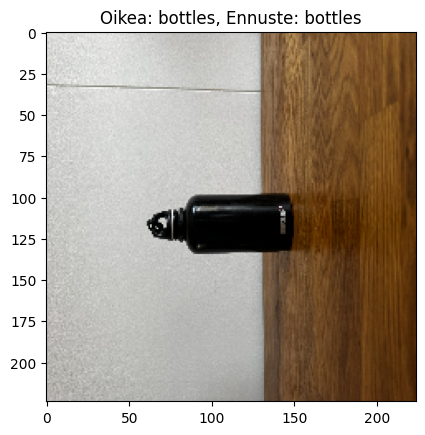

In [12]:
import numpy as np

images, labels = next(iter(test_ds))
preds = model3.predict(images)
pred_labels = np.argmax(preds, axis=1)

class_names = train_ds.class_names

for i in range(5):
    plt.imshow(images[i].numpy().astype("uint8"))
    
    true_label = class_names[labels[i]]
    pred_label = class_names[pred_labels[i]]
    
    plt.title(f"Oikea: {true_label}, Ennuste: {pred_label}")
    plt.show()